# Lab 8: Fixing a Broken Cyclotron with Optimization

---

## The Situation

You've inherited a cyclotron but something is wrong. The radiofrequency (RF) voltage that gives protons their kick is oscillating at the wrong frequency. It's not synchronized with the protons' natural orbit frequency, so instead of accelerating, the protons just wander around and nothing gets accelerated.

Your job: **find the magnetic field strength $B$ that makes the proton orbit frequency exactly match the target RF frequency of 15.2 MHz.**

You'll do this three ways:
1. Plot the mismatch and eyeball the answer
2. Use `scipy.optimize.minimize` with one optimizer
3. Compare two optimizers and decide which is better for this job

---

## Introduction

A proton moving in a magnetic field $B$ travels in a circle. The frequency of that circular orbit — called the **cyclotron frequency** — depends only on $B$ and the proton's charge-to-mass ratio:

$$f_{\text{cyclotron}}(B) = \frac{qB}{2\pi m}$$

where:
- $q = 1.6 \times 10^{-19}$ C (proton charge)
- $m = 1.67 \times 10^{-27}$ kg (proton mass)
- $B$ is the magnetic field strength in Tesla

Notice: the orbit frequency doesn't depend on the proton's speed or the circle's radius — just $B$. This is what makes cyclotrons possible.

The RF voltage in our broken cyclotron is stuck at $f_{\text{target}} = 15.2$ MHz. We need to find $B$ such that $f_{\text{cyclotron}}(B) = f_{\text{target}}$.

We'll measure the **mismatch** (how far off we are) using a squared error:

$$\text{cost}(B) = \left(f_{\text{cyclotron}}(B) - f_{\text{target}}\right)^2$$

When this cost is zero, the cyclotron is fixed.

---
## Section 0: Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("Imports successful. Ready to fix the cyclotron.")

Imports successful. Ready to fix the cyclotron.


---
## Section 1: Physical Constants and Parameters
These are the fixed physical constants and the parameters of the broken cyclotron.

In [ ]:
# Physical constants
q = 1.6e-19       # proton charge, Coulombs
m = 1.67e-27      # proton mass, kg

# Target RF frequency (the broken cyclotron is stuck here)
f_target = 15.2e6  # Hz  (15.2 MHz)

# Search range for B (Tesla)
B_min = 0.5
B_max = 2.0

print(f"Target frequency: {f_target/1e6:.1f} MHz")
print(f"Search range: B = {B_min} T to {B_max} T")

Target frequency: 15.2 MHz
Search range: B = 0.5 T to 2.0 T


---
## Section 2: The Physics Function

Here are two functions you'll use throughout the lab: You need to update them.

- `cyclotron_freq(B)` — returns the proton orbit frequency for a given field $B$
- `cost(B_array)` — returns the squared mismatch between the orbit frequency and the target

Notice that `cost` takes a NumPy array `B_array` and unpacks `B_array[0]`. This is because `scipy.optimize.minimize` always passes its parameter as an array, even when there's just one number.

In [ ]:
def cyclotron_freq(B):
    """
    Compute the cyclotron frequency for a proton in magnetic field B.

    Parameters
    ----------
    B : float or np.ndarray
        Magnetic field strength in Tesla.

    Returns
    -------
    float or np.ndarray
        Cyclotron frequency in Hz.
    """
    freq = (q / m) / (2*np.pi) * B
    return freq


def cost(B_array):
    """
    Cost function: squared frequency mismatch.

    Parameters
    ----------
    B_array : np.ndarray
        1-element array containing the magnetic field to test.
        (scipy.optimize.minimize always passes arrays)

    Returns
    -------
    float
        Squared difference (f_cyclotron - f_target)^2.
    """
    B = B_array[0]  # unpack the single value from the array
    f = cyclotron_freq(B)
    return (f - f_target) ** 2


# Quick sanity check
B_test = 1.0  # Tesla
print(f"At B = {B_test} T:  f_cyclotron = {cyclotron_freq(B_test)/1e6:.3f} MHz")
print(f"Cost at B = {B_test} T: {cost(np.array([B_test])):.4e}")
print("\n✓ Functions defined successfully.")

At B = 1.0 T:  f_cyclotron = 15.248 MHz
Cost at B = 1.0 T: 2.3404e+09

✓ Functions defined successfully.


## Section 3: Plot the Mismatch — Find the Minimum by Eye*

Before we try to optimize, let's understand what we're minimizing. We'll sweep $B$ across the full search range and plot the cost function. The minimum tells us where the cyclotron frequency matches the target.

**After you run this:** Look at the plot and note roughly where the minimum is. Write it down — you'll compare it to the optimizer's answer in a moment.

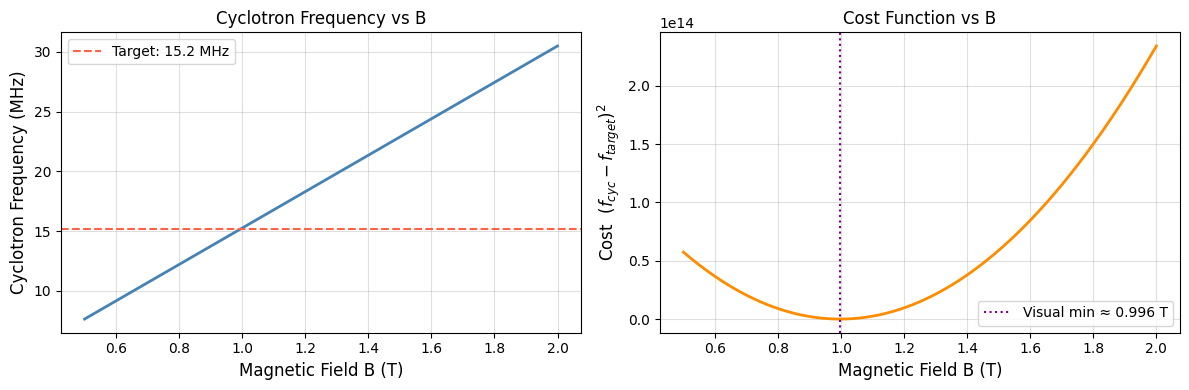


Visual estimate of optimal B: 0.9960 T
Cyclotron frequency at that B: 15.1873 MHz
Target frequency:              15.2000 MHz


In [ ]:
# Create an array of 500 B values from B_min to B_max
B_sweep = np.linspace(B_min, B_max, 500)

# Compute the cyclotron frequency at each B
# cyclotron_freq works on arrays thanks to NumPy broadcasting
f_sweep = cyclotron_freq(B_sweep)

# Compute the cost (squared mismatch) at each B
cost_sweep = (f_sweep - f_target) ** 2

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: cyclotron frequency vs B
axes[0].plot(B_sweep, f_sweep / 1e6, color='steelblue', linewidth=2)
axes[0].axhline(f_target / 1e6, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Target: {f_target/1e6:.1f} MHz')
axes[0].set_xlabel('Magnetic Field B (T)', fontsize=12)
axes[0].set_ylabel('Cyclotron Frequency (MHz)', fontsize=12)
axes[0].set_title('Cyclotron Frequency vs B')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Right panel: cost function vs B
axes[1].plot(B_sweep, cost_sweep, color='darkorange', linewidth=2)
axes[1].set_xlabel('Magnetic Field B (T)', fontsize=12)
axes[1].set_ylabel('Cost  $(f_{cyc} - f_{target})^2$', fontsize=12)
axes[1].set_title('Cost Function vs B')
axes[1].grid(True, alpha=0.4)

# Mark the minimum of the cost curve
B_eye = B_sweep[np.argmin(cost_sweep)]
axes[1].axvline(B_eye, color='purple', linestyle=':', linewidth=1.5,
                label=f'Visual min ≈ {B_eye:.3f} T')
axes[1].legend()

plt.tight_layout()
plt.savefig('cost_function_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nVisual estimate of optimal B: {B_eye:.4f} T")
print(f"Cyclotron frequency at that B: {cyclotron_freq(B_eye)/1e6:.4f} MHz")
print(f"Target frequency:              {f_target/1e6:.4f} MHz")

### Section 3 Check
**Look for:**
- Two plots: a linear frequency curve on the left, a bowl-shaped cost curve on the right
- The cost curve has a clear single minimum somewhere between 0.5 and 2.0 T
- The visual minimum printed below the plot is somewhere around 1.0 T (ballpark — exact answer comes later)

If you see an error, check that Section 0 and Section 1 cells ran without errors first.

---
## Section 4: First Optimizer — L-BFGS-B

Now we'll use `scipy.optimize.minimize` to find the exact minimum.

**How `minimize` works (quick reminder):**
- It starts at an initial guess `x0`
- It repeatedly evaluates the cost function and adjusts its guess to go downhill
- It stops when the improvement becomes tiny
- It returns a result object; the answer is in `result.x`

**L-BFGS-B** is a gradient-based method — it estimates the slope of the cost function at each step to decide which direction to step. It's fast and accurate for smooth functions like ours.

**Your task:** Fill in the initial guess `x0`. Pick any value inside the search range, like `[1.0]`.  
(Remember: `x0` must be a list or array, even for a single variable — that's what `minimize` needs).
Also finish the code to run lbfgs.

In [ ]:
# ============================================================
# CHANGE THIS LINE: set your initial guess for B (in Tesla)
# Must be a list with one element, e.g. [1.0] or [0.8] or [1.5]
x0 = [0.8]   # <-- replace ??? with a number between 0.5 and 2.0
# ============================================================

# Bounds tell the optimizer to stay within [B_min, B_max]
bounds = [(B_min, B_max)]

# Run the optimizer
result_lbfgsb = minimize(cost, x0, method = 'L-BFGS-B', options = {'maxiter':1000}, bounds = bounds)

# Extract and display the result
B_lbfgsb = result_lbfgsb.x[0]
f_lbfgsb = cyclotron_freq(B_lbfgsb)

print("=== L-BFGS-B Result ===")
print(f"  Optimal B:           {B_lbfgsb:.6f} T")
print(f"  Cyclotron freq:      {f_lbfgsb/1e6:.6f} MHz")
print(f"  Target freq:         {f_target/1e6:.6f} MHz")
print(f"  Residual mismatch:   {abs(f_lbfgsb - f_target):.4f} Hz")
print(f"  Cost at solution:    {result_lbfgsb.fun:.4e}")
print(f"  Converged?           {result_lbfgsb.success}")
print(f"  # function calls:    {result_lbfgsb.nfev}")
print(f"  Message:             {result_lbfgsb.message}")

=== L-BFGS-B Result ===
  Optimal B:           0.996827 T
  Cyclotron freq:      15.200000 MHz
  Target freq:         15.200000 MHz
  Residual mismatch:   0.0624 Hz
  Cost at solution:    3.8999e-03
  Converged?           True
  # function calls:    18
  Message:             CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


### Section 4 Check
**You're free to move on if:**
- `Converged?` shows `True`
- The residual mismatch is very small (much less than 1 Hz)
- The optimal B is close to your visual estimate from Section 3

**If you get a `SyntaxError`:** You left `???` in place — replace it with a number like `[1.0]`.

**If `Converged?` shows `False`:** Try a different starting point — pick a value closer to the visual minimum you found.

---
## Section 5: Second Optimizer — Nelder-Mead

Now we'll run the same problem with **Nelder-Mead**.

**How Nelder-Mead is different:**  
L-BFGS-B estimates the *gradient* (the slope) of the cost function to decide where to step. Nelder-Mead doesn't do that at all — it only compares function *values* at a few test points, then shrinks and reshapes a geometric shape (a "simplex") around the minimum. This makes it:

- **Slower** — it needs more function evaluations to find the answer
- **More robust** — it can handle cost functions that aren't smooth, or where gradients are hard to compute
- **Can't use bounds** directly (we'll just use the same starting point)

We're using the same `x0` you chose in Section 4.

In [ ]:
# Run Nelder-Mead with the same starting point as before
result_nm = minimize(cost, x0, method = 'nelder-mead', options = {'maxiter':1000}, bounds = bounds)
    # Note: Nelder-Mead does not accept a 'bounds' argument


B_nm = result_nm.x[0]
f_nm = cyclotron_freq(B_nm)

print("=== Nelder-Mead Result ===")
print(f"  Optimal B:           {B_nm:.6f} T")
print(f"  Cyclotron freq:      {f_nm/1e6:.6f} MHz")
print(f"  Target freq:         {f_target/1e6:.6f} MHz")
print(f"  Residual mismatch:   {abs(f_nm - f_target):.4f} Hz")
print(f"  Cost at solution:    {result_nm.fun:.4e}")
print(f"  Converged?           {result_nm.success}")
print(f"  # function calls:    {result_nm.nfev}")
print(f"  Message:             {result_nm.message}")

=== Nelder-Mead Result ===
  Optimal B:           0.996827 T
  Cyclotron freq:      15.200000 MHz
  Target freq:         15.200000 MHz
  Residual mismatch:   0.0078 Hz
  Cost at solution:    6.1274e-05
  Converged?           True
  # function calls:    58
  Message:             Optimization terminated successfully.


---
## Section 6: Compare the Two Optimizers

Let's put both results side by side and visualize where each optimizer landed.

Metric                           L-BFGS-B  Nelder-Mead
Optimal B (T)                    0.996827     0.996827
f_cyclotron (MHz)               15.200000    15.200000
Mismatch (Hz)                      0.0624       0.0078
Cost at solution               3.8999e-03   6.1274e-05
# function calls                       18           58
Converged?                           True         True


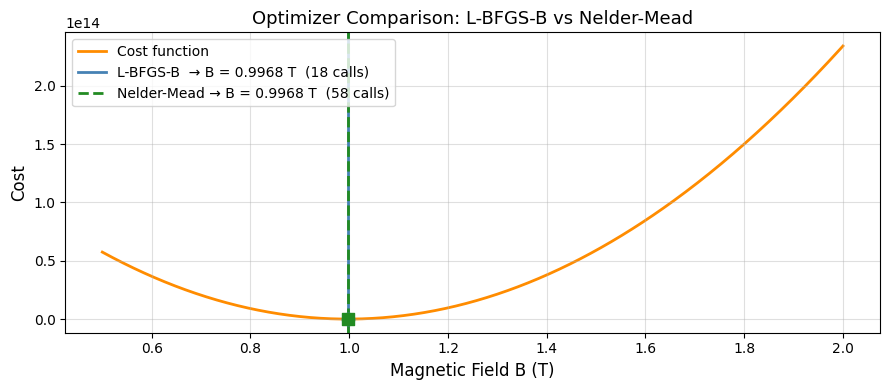

In [ ]:
# --- Side-by-side summary table ---
print("=" * 55)
print(f"{'Metric':<28} {'L-BFGS-B':>12} {'Nelder-Mead':>12}")
print("=" * 55)
print(f"{'Optimal B (T)':<28} {B_lbfgsb:>12.6f} {B_nm:>12.6f}")
print(f"{'f_cyclotron (MHz)':<28} {f_lbfgsb/1e6:>12.6f} {f_nm/1e6:>12.6f}")
print(f"{'Mismatch (Hz)':<28} {abs(f_lbfgsb-f_target):>12.4f} {abs(f_nm-f_target):>12.4f}")
print(f"{'Cost at solution':<28} {result_lbfgsb.fun:>12.4e} {result_nm.fun:>12.4e}")
print(f"{'# function calls':<28} {result_lbfgsb.nfev:>12d} {result_nm.nfev:>12d}")
print(f"{'Converged?':<28} {str(result_lbfgsb.success):>12} {str(result_nm.success):>12}")
print("=" * 55)

# --- Visualization ---
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(B_sweep, cost_sweep, color='darkorange', linewidth=2, label='Cost function', zorder=1)

ax.axvline(B_lbfgsb, color='steelblue', linewidth=2, linestyle='-',
           label=f'L-BFGS-B  → B = {B_lbfgsb:.4f} T  ({result_lbfgsb.nfev} calls)', zorder=2)
ax.axvline(B_nm, color='forestgreen', linewidth=2, linestyle='--',
           label=f'Nelder-Mead → B = {B_nm:.4f} T  ({result_nm.nfev} calls)', zorder=2)

ax.scatter([B_lbfgsb], [result_lbfgsb.fun], color='steelblue', s=80, zorder=3)
ax.scatter([B_nm], [result_nm.fun], color='forestgreen', s=80, marker='s', zorder=3)

ax.set_xlabel('Magnetic Field B (T)', fontsize=12)
ax.set_ylabel('Cost', fontsize=12)
ax.set_title('Optimizer Comparison: L-BFGS-B vs Nelder-Mead', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 7: Reflection Questions

Look at your comparison table and plot, then answer these three questions in your report:

**Q1.** Both optimizers found essentially the same $B$. Does that mean either one would have been fine for this problem? What property of the cost function makes it easy for both methods?

**Q2.** One optimizer used more function calls than the other. Which one, and why does that make sense given how each method works?

**Q3.** The cost function we minimized was the *squared* mismatch $(f - f_{\text{target}})^2$. What would happen if we used the *absolute* mismatch $|f - f_{\text{target}}|$ instead? Would L-BFGS-B still work as well? (Hint: think about the derivative at the minimum.)

---
## Section 8: Final Verification


Let's confirm the cyclotron is fixed by checking the L-BFGS-B answer satisfies all our requirements.

In [ ]:
B_solution = B_lbfgsb
f_solution = cyclotron_freq(B_solution)

tolerance_Hz = 1.0  # We demand the mismatch to be less than 1 Hz

mismatch = abs(f_solution - f_target)
within_bounds = B_min <= B_solution <= B_max
accurate = mismatch < tolerance_Hz

print("╔══════════════════════════════════════════╗")
print("║         CYCLOTRON REPAIR REPORT          ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Required field:   {B_solution:.4f} T             ║")
print(f"║  Achieved freq:    {f_solution/1e6:.4f} MHz         ║")
print(f"║  Target freq:      {f_target/1e6:.4f} MHz         ║")
print(f"║  Mismatch:         {mismatch:.4f} Hz             ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Within bounds?    {' YES' if within_bounds else 'NO'}                   ║")
print(f"║  Accurate (<1 Hz)? {' YES' if accurate else ' NO'}                   ║")
print("╠══════════════════════════════════════════╣")
if within_bounds and accurate:
    print("║     CYCLOTRON REPAIRED. Good work.      ║")
else:
    print("║     Something's off — check Section 4.  ║")
print("╚══════════════════════════════════════════╝")

╔══════════════════════════════════════════╗
║         CYCLOTRON REPAIR REPORT          ║
╠══════════════════════════════════════════╣
║  Required field:   0.9968 T             ║
║  Achieved freq:    15.2000 MHz         ║
║  Target freq:      15.2000 MHz         ║
║  Mismatch:         0.0624 Hz             ║
╠══════════════════════════════════════════╣
║  Within bounds?     YES                   ║
║  Accurate (<1 Hz)?  YES                   ║
╠══════════════════════════════════════════╣
║     CYCLOTRON REPAIRED. Good work.      ║
╚══════════════════════════════════════════╝
